In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [10]:
data = pd.read_csv('../data/advertising.csv')

train_data, test_data = train_test_split(data, test_size=0.2)

X_train = train_data[['TV', 'Radio', 'Newspaper']]
y_train = train_data['Sales']
X_test = test_data[['TV', 'Radio', 'Newspaper']]
y_test = test_data['Sales']

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [17]:
for i, col in enumerate(X_train_scaled.columns):
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_scaled[col], y_train)
    plt.title(f"Scatter plot of {col} vs Target")
    plt.xlabel(col)
    plt.ylabel("Target")
    plt.tight_layout()
    # plt.show()
    plt.close()

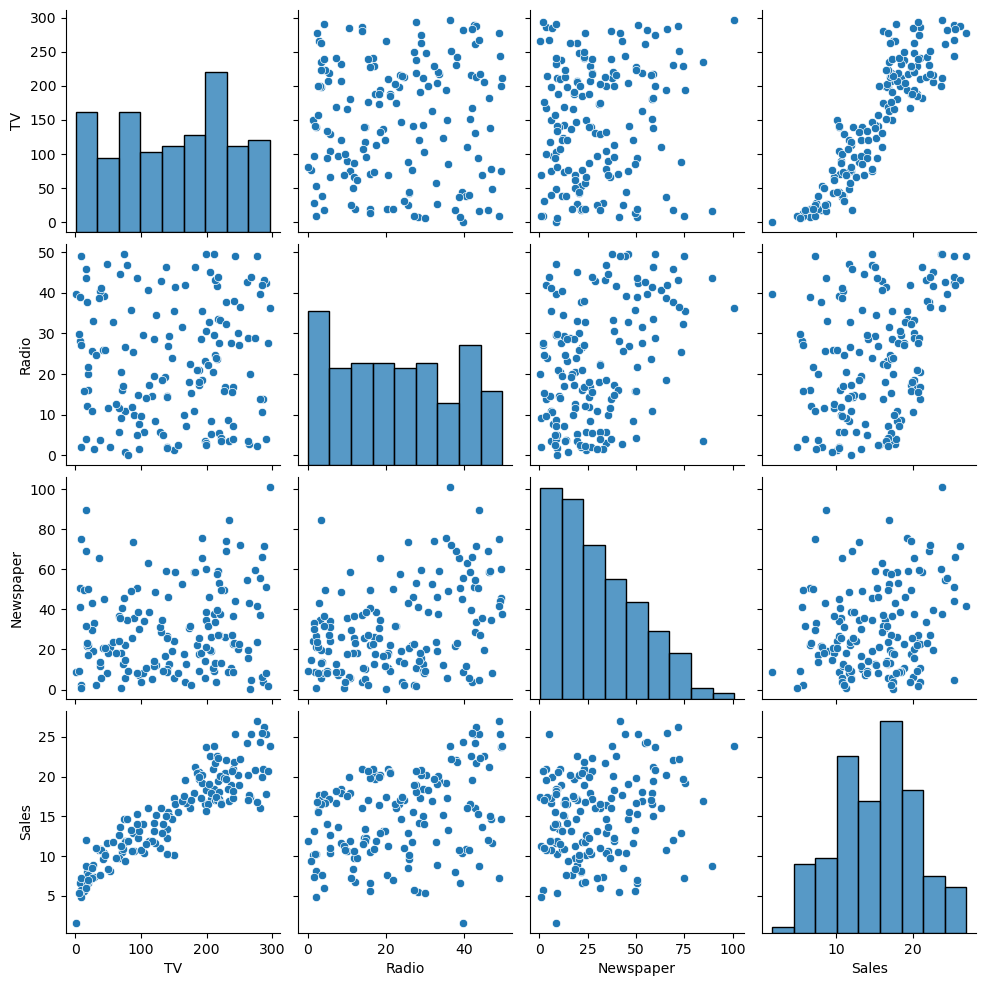

In [18]:
train_data_for_plot = X_train.copy()
train_data_for_plot['Sales'] = y_train

sns.pairplot(train_data_for_plot)
plt.show()
plt.close()

Jest zauważalna liniowa korelacja TV i Sales, tutaj kombinowanie z regresją może mieć sens

W poprzednich zadanich było mniej kategorii, tutaj jedynie TV jest skoloerowane z Sales, reszta pomimo, że ma dosyć proste rozkłady danych (np jednostajny dla radia) to nie sugeruję mi to niczego więcej. Nie ma też zauważalnych outlayer'rów

In [14]:
from sklearn.linear_model import LinearRegression
import sklearn.metrics as skm

model_lr_raw_data = LinearRegression()
model_lr_scaled_data = LinearRegression()

In [15]:
def model_train_eval(model, X_, y_, X_test_, y_test_, variant):
    model.fit(X_, y_)

    print(f"Coefficients: {model.coef_}, Intercept: {model.intercept_}")

    y_pred = model.predict(X_test_)
    rsc = model.score(X_test_, y_test_)
    mse = skm.mean_squared_error(y_test_, y_pred)
    mape = skm.mean_absolute_percentage_error(y_test, y_pred)
    mae = skm.mean_absolute_error(y_test, y_pred)

    return dict(variant=variant, MSE=mse, MAE=mae, MAPE=mape, Rsq=rsc, Coefficients=model.coef_, Intercept=model.intercept_)

In [16]:
all_results = []

all_results.append(model_train_eval(LinearRegression(fit_intercept=True), X_train, y_train, X_test, y_test, "raw"))
all_results.append(model_train_eval(LinearRegression(fit_intercept=True), X_train_scaled, y_train, X_test_scaled, y_test, "scaled"))

results = pd.DataFrame(all_results)
results

Coefficients: [ 0.05476066  0.10598583 -0.00020127], Intercept: 4.610013578818016
Coefficients: [ 4.70922415e+00  1.55062943e+00 -4.32081149e-03], Intercept: 15.166875


,variant,MSE,MAE,MAPE,Rsq,Coefficients,Intercept
0,raw,1.85549,1.076443,0.089243,0.931326,"[0.054760658352985894, 0.10598582509035322, -0...",4.610014
1,scaled,1.85549,1.076443,0.089243,0.931326,"[4.7092241482203026, 1.5506294306950414, -0.00...",15.166875


Wyniki te same ... wszystko jest podobnego, niedużego rzędu wielkości, wydaje mi się, że to raczej rozsądne
MSE MASE są małe ale R^2 aż 0.93, tutaj regresja zdaje się dobrze pasować w obu przypadkach.